In [1]:
%matplotlib inline

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skimage.io as skio
import matplotlib.patches as mpatches
import scipy.stats as stats
from collections import defaultdict
import tqdm
import shap
from sklearn.model_selection import KFold, GridSearchCV, cross_val_predict
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import ElasticNet, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import HuberRegressor, RANSACRegressor
from sklearn.svm import SVR
import joblib

import warnings
warnings.filterwarnings(action='ignore')#,category=sklearn.exceptions.ConvergenceWarning)

/opt/anaconda3/envs/cawt-urfi/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def cut_image(img,low=0.2,high=0.8):
    h,w = img.shape[:2]
    return img[int(low*h):int(high*h),int(low*w):int(high*w),:]

def calculate_features(img,percentile_levels=[5,15,25,50,75,85,95],low=0.2,high=0.8):
    features_dict = {}
    for color_chan_id,color in enumerate('RGB'):
        for percentile_level in percentile_levels:
            
            cutted_image = cut_image(img,low=low,high=high)
            feature_value = np.percentile(cutted_image[:,:,color_chan_id].ravel(),percentile_level)
            feature_name = f'{color}_p={percentile_level}'
            
            features_dict[feature_name] = feature_value
    return features_dict

# Classify severity function
def classify_severity(hb):
    if hb < 8.0: return 0  # Severe
    elif hb < 11.0: return 1  # Moderate
    elif hb < 12.0: return 2  # Mild
    else: return 3  # Normal

def explain_model_with_shap(model_name, fitted_pipeline, X_background, X_explain):
    model = fitted_pipeline.named_steps["regressor"]
    scaler = fitted_pipeline.named_steps["scaler"]
    X_explain_scaled = scaler.transform(X_explain)
    X_background_scaled = scaler.transform(X_background)

    if model_name in ["ElasticNet", "Ridge", "Lasso"]:
        explainer = shap.LinearExplainer(model, X_background_scaled)
        shap_values = explainer(X_explain_scaled)
    elif model_name in ["RandomForest", "GradientBoosting"]:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer(X_explain_scaled)
    elif model_name == "SVR":
        explainer = shap.KernelExplainer(model.predict, X_background_scaled)
        shap_values = explainer.shap_values(X_explain_scaled)
    else:
        raise ValueError(f"SHAP explainer not defined for model: {model_name}")
    
    return explainer, shap_values

In [3]:
# DATA_DIR = os.path.expanduser("~/cp-anemia-detection/data/fingernail-anemia")
DATA_DIR = "/Users/romerocruzsa/Workspace/Projects/Research/cp-anemia-detection/data/fingernail-anemia"
CSV_PATH = os.path.join(DATA_DIR, "metadata.csv")
metadata = pd.read_csv(CSV_PATH)

In [4]:
metadata.head()

,PATIENT_ID,MEASUREMENT_DATE,HB_LEVEL_GperL,NAIL_BOUNDING_BOXES,SKIN_BOUNDING_BOXES
0,1,14b0293a34344cc4fba0fa39d5370c52,134.0,"[[251, 447, 302, 505], [123, 429, 183, 483], [...","[[267, 586, 324, 627], [148, 556, 200, 614], [..."
1,2,14b0293a34344cc4fba0fa39d5370c52,108.0,"[[236, 503, 281, 556], [148, 457, 195, 514], [...","[[252, 612, 294, 647], [162, 585, 212, 632], [..."
2,5,14b0293a34344cc4fba0fa39d5370c52,84.0,"[[244, 508, 277, 562], [183, 448, 220, 505], [...","[[264, 629, 303, 662], [193, 584, 232, 619], [..."
3,6,14b0293a34344cc4fba0fa39d5370c52,138.0,"[[311, 456, 363, 521], [182, 408, 237, 471], [...","[[318, 609, 380, 650], [189, 562, 245, 616], [..."
4,7,14b0293a34344cc4fba0fa39d5370c52,119.0,"[[29, 513, 78, 556], [119, 435, 165, 479], [18...","[[29, 635, 79, 678], [117, 564, 175, 615], [20..."


In [5]:
metadata["HB_LEVEL_GperDeciL"] = metadata["HB_LEVEL_GperL"]/10
metadata.sample(5) 

,PATIENT_ID,MEASUREMENT_DATE,HB_LEVEL_GperL,NAIL_BOUNDING_BOXES,SKIN_BOUNDING_BOXES,HB_LEVEL_GperDeciL
200,277,e58f0edcc264ff6781b44dd9a387e2bf,124.0,"[[323, 509, 380, 584], [228, 435, 289, 501], [...","[[320, 645, 385, 709], [212, 583, 284, 680], [...",12.4
79,102,bfee10908fb5aeb64c85d2d4259e8812,149.0,"[[314, 539, 361, 582], [229, 461, 281, 515], [...","[[322, 654, 365, 705], [240, 615, 286, 659], [...",14.9
99,134,e3981224ab5bcea1150ac871aa3d649b,141.0,"[[300, 554, 358, 606], [220, 499, 273, 548], [...","[[298, 686, 357, 727], [216, 647, 264, 703], [...",14.1
95,129,e3981224ab5bcea1150ac871aa3d649b,148.0,"[[332, 534, 390, 593], [212, 485, 262, 540], [...","[[343, 660, 397, 721], [217, 594, 274, 662], [...",14.8
96,130,e3981224ab5bcea1150ac871aa3d649b,152.0,"[[340, 591, 389, 655], [259, 497, 318, 562], [...","[[338, 722, 386, 779], [243, 653, 292, 714], [...",15.2


In [6]:
metadata['NAIL_BOUNDING_BOXES'] = metadata['NAIL_BOUNDING_BOXES'].apply(json.loads)
metadata['SKIN_BOUNDING_BOXES'] = metadata['SKIN_BOUNDING_BOXES'].apply(json.loads)

In [7]:
# image_folder = 'data/photo/'
# N_MAX_IMAGES = 1

# for j,(_, row) in enumerate(metadata.sample(N_MAX_IMAGES).iterrows()):
    
#     if j ==  N_MAX_IMAGES:
#         break
    
#     label = 'Anemic' if row.HB_LEVEL_GperDeciL < 12.0 else 'Non-anemic'
#     img_path = os.path.join(DATA_DIR ,label, f'{row.PATIENT_ID}.jpg')
    
#     img = skio.imread(img_path)
    
#     plt.figure(figsize=(7,5))
#     plt.imshow(img)
    
#     nails_bboxes = row.NAIL_BOUNDING_BOXES
#     skin_bboxes  = row.SKIN_BOUNDING_BOXES
    
#     ax = plt.gca()
    
#     for _color,_bboxes in zip(['r','b'],[nails_bboxes,skin_bboxes]):
#         for top,left,bot,right in _bboxes:
            
#             w,h = right-left,bot-top
            
#             rectangle = mpatches.Rectangle(xy=(left,top),width=w,height=h,fill=None,
#                                            color=_color,linewidth=1.5)
            
#             ax.add_patch(rectangle)
            
#     white_region_rectangle = mpatches.Rectangle(xy=(350,300),width=50,height=50,fill=None,
#                                            color='green',linewidth=1.5)
#     ax.add_patch(white_region_rectangle)
    
#     plt.title(f"PATIENT ID : {row.PATIENT_ID}")
    
#     fig,axs = plt.subplots(2,3,figsize=(13,8))
#     axs = axs.ravel()
    
#     all_bboxes = nails_bboxes + skin_bboxes
    
#     for i,(top,left,bot,right) in enumerate(all_bboxes):
#         axs[i].imshow(img[top:bot,left:right],aspect='auto')
#         if i == 1:
#             axs[i].set_title("Segmented nails regions")
#         if i == 4:
#             axs[i].set_title("Segmented skin regions")
        
#     plt.show()

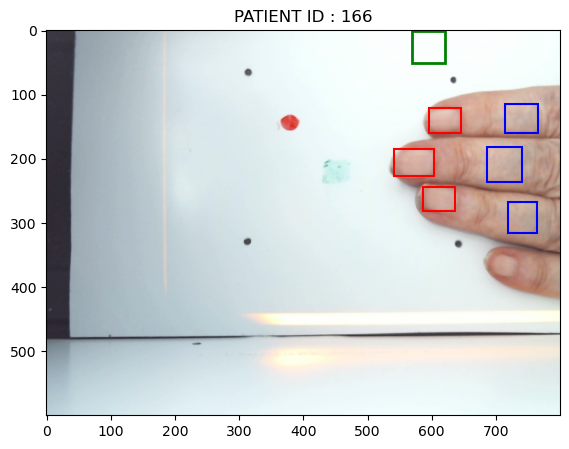

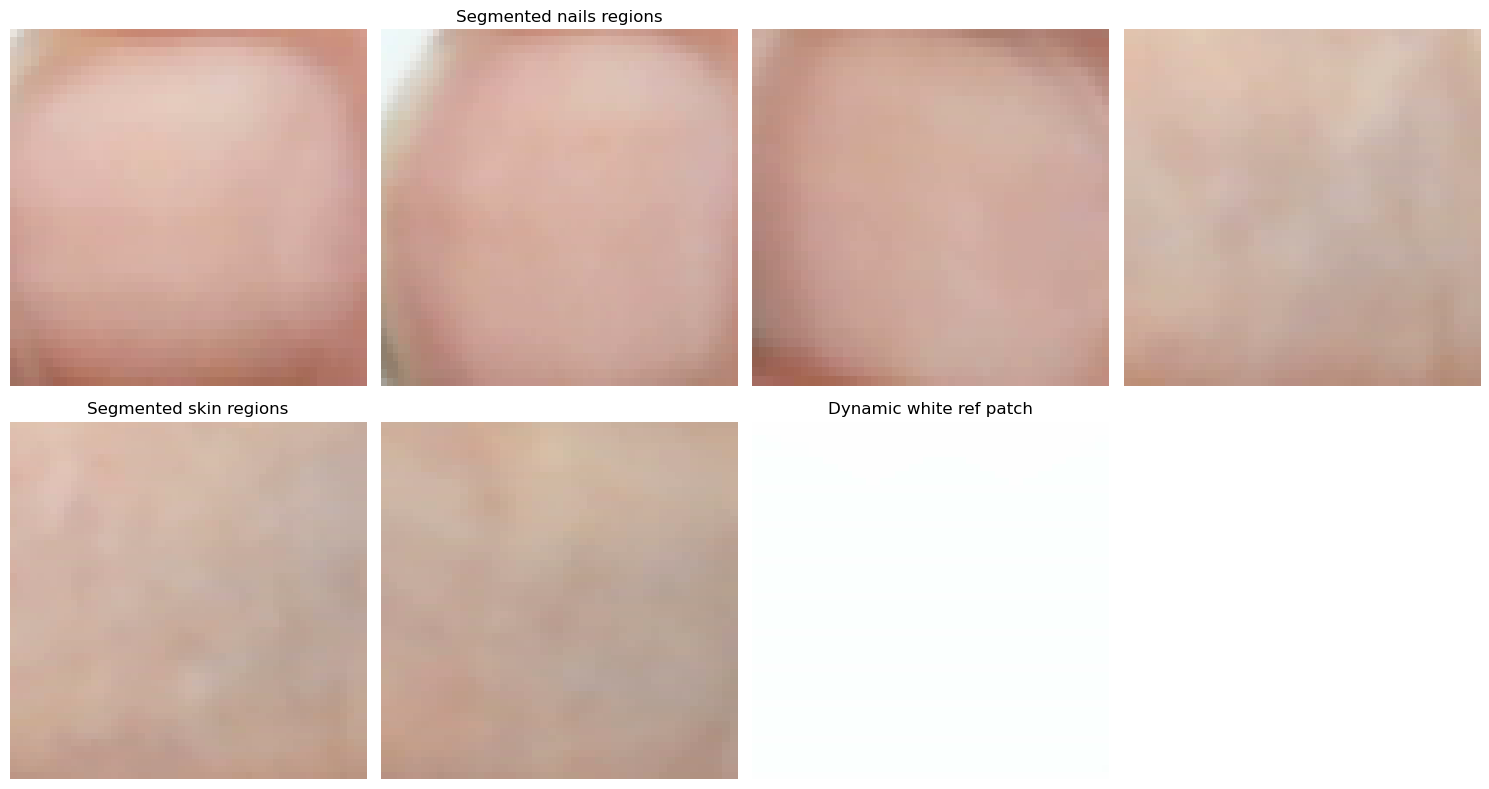

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import skimage.io as skio

# Helper to find brightest patch
def find_brightest_patch(image, patch_size=(50, 50), stride=10):
    gray = np.mean(image, axis=2)  # Convert to grayscale using mean
    h, w = gray.shape
    ph, pw = patch_size
    max_mean = -1
    best_coords = (0, 0)

    for y in range(0, h - ph + 1, stride):
        for x in range(0, w - pw + 1, stride):
            patch = gray[y:y + ph, x:x + pw]
            patch_mean = np.mean(patch)
            if patch_mean > max_mean:
                max_mean = patch_mean
                best_coords = (y, x)

    return best_coords  # (top, left)

# Your parameters
image_folder = 'data/photo/'
N_MAX_IMAGES = 1
PATCH_SIZE = (50, 50)  # 50x50 patch

for j, (_, row) in enumerate(metadata.sample(N_MAX_IMAGES).iterrows()):
    if j == N_MAX_IMAGES:
        break

    label = 'Anemic' if row.HB_LEVEL_GperDeciL < 12.0 else 'Non-anemic'
    img_path = os.path.join(DATA_DIR, label, f'{row.PATIENT_ID}.jpg')

    img = skio.imread(img_path)

    plt.figure(figsize=(7, 5))
    plt.imshow(img)

    nails_bboxes = row.NAIL_BOUNDING_BOXES
    skin_bboxes = row.SKIN_BOUNDING_BOXES

    ax = plt.gca()

    # Draw nails and skin bounding boxes
    for _color, _bboxes in zip(['r', 'b'], [nails_bboxes, skin_bboxes]):
        for top, left, bot, right in _bboxes:
            w, h = right - left, bot - top
            rectangle = mpatches.Rectangle(xy=(left, top), width=w, height=h,
                                           fill=None, color=_color, linewidth=1.5)
            ax.add_patch(rectangle)

    # 🔥 Find brightest region dynamically
    top, left = find_brightest_patch(img, patch_size=PATCH_SIZE, stride=10)
    box_h, box_w = PATCH_SIZE

    # Draw green rectangle for the white reference
    white_region_rectangle = mpatches.Rectangle(xy=(left, top), width=box_w, height=box_h,
                                                 fill=None, color='green', linewidth=2)
    ax.add_patch(white_region_rectangle)

    plt.title(f"PATIENT ID : {row.PATIENT_ID}")
    plt.show()

    # --- Visualize all the crops ---
    fig, axs = plt.subplots(2, 4, figsize=(15, 8))
    axs = axs.ravel()

    all_bboxes = nails_bboxes + skin_bboxes
    all_bboxes.append((top, left, top + box_h, left + box_w))  # Add the white patch!

    for i, (top, left, bot, right) in enumerate(all_bboxes):
        if i >= len(axs): break
        axs[i].imshow(img[top:bot, left:right], aspect='auto')
        if i == 1:
            axs[i].set_title("Segmented nails regions")
        if i == 4:
            axs[i].set_title("Segmented skin regions")
        if i == 6:
            axs[i].set_title("Dynamic white ref patch")

    for ax in axs:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


In [9]:
images = defaultdict(list)

for j, (_, row) in tqdm.tqdm(enumerate(metadata.iterrows())):
    label = 'Anemic' if row.HB_LEVEL_GperDeciL < 12.0 else 'Non-anemic'
    img_path = os.path.join(DATA_DIR ,label, f'{row.PATIENT_ID}.jpg')
    img = skio.imread(img_path)

    nails_bboxes = row.NAIL_BOUNDING_BOXES
    skin_bboxes = row.SKIN_BOUNDING_BOXES

    # ➕ Load NAIL crops
    for finger_num, (top, left, bot, right) in enumerate(nails_bboxes, start=1):
        key = f'NAIL_{finger_num}'
        images[key].append(img[top:bot, left:right])

    # # ➕ Load SKIN crops
    # for patch_num, (top, left, bot, right) in enumerate(skin_bboxes, start=1):
    #     key = f'SKIN_{patch_num}'
    #     images[key].append(img[top:bot, left:right])

    # ➕ White reference region (still using hardcoded region)
    images['WHITE_REF'].append(img[350:400, 300:350])

250it [00:02, 121.65it/s]


In [10]:
# Step 1: Compute white reference medians
white_ref_median = pd.DataFrame({
    f'{color}': [np.median(img[:, :, chan].ravel()) for img in images['WHITE_REF']]
    for chan, color in enumerate("RGB")
})

# Step 2: Compute normalized RGB features for each nail
mean_rgb_per_nail = []
for i in range(1, 4):  # Assuming 3 nails per patient
    key = f'NAIL_{i}'
    channel_means = []
    for idx, img in enumerate(images[key]):
        mean_values = {
            f'{key}_{color}_mean': np.mean(img[:, :, chan]) / white_ref_median[color].iloc[idx]
            for chan, color in enumerate("RGB")
        }
        channel_means.append(mean_values)
    mean_rgb_per_nail.append(pd.DataFrame(channel_means))

# Step 3: Compute normalized RGB features for each skin patch
mean_rgb_per_skin = []
for i in range(1, 4):  # Assuming 3 nails per patient
    key = f'SKIN_{i}'
    channel_means = []
    for idx, img in enumerate(images[key]):
        mean_values = {
            f'{key}_{color}_mean': np.mean(img[:, :, chan]) / white_ref_median[color].iloc[idx]
            for chan, color in enumerate("RGB")
        }
        channel_means.append(mean_values)
    mean_rgb_per_skin.append(pd.DataFrame(channel_means))


# Step 4: Combine everything into one final DataFrame
features = pd.concat(mean_rgb_per_nail + mean_rgb_per_skin, axis=1)

In [11]:
# cols = features_df.columns[:-3]
# features = features_df[cols]
# target = features_df['HB_LEVEL_GperDeciL']

target = metadata['HB_LEVEL_GperDeciL']

0.276 	 0.44


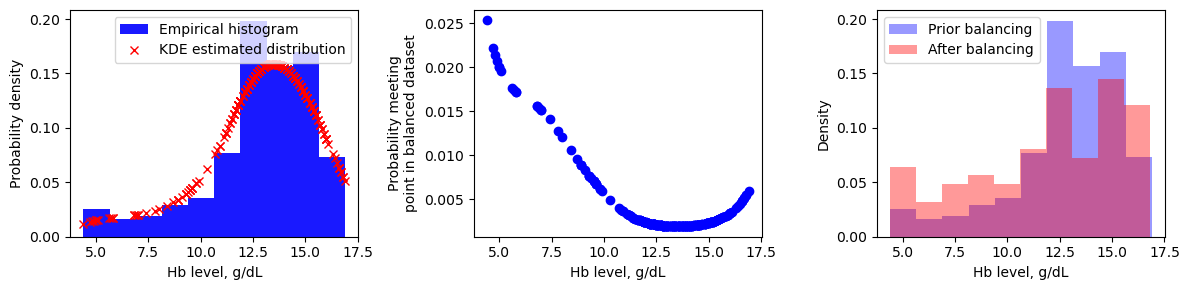

In [12]:
np.random.seed(42)

target_kde = stats.gaussian_kde(target,bw_method=0.5)(target)
weights = 1/target_kde
weights /= np.sum(weights)

patient_ids = metadata['PATIENT_ID']
balanced_patient_ids = np.random.choice(patient_ids,size=100,replace=False,p=weights)
balancing_mask = metadata['PATIENT_ID'].isin(balanced_patient_ids).values
np.mean(target < 12.0)
np.mean(target[balancing_mask] < 12.0)

print(f"{np.mean(target < 12.0)} \t {np.mean(target[balancing_mask] < 12.0)}")

plt.figure(figsize=(12,3))
plt.subplot(1,3,1)

plt.hist(target,density=True,label='Empirical histogram',color='b',alpha=0.9)
plt.plot(target,target_kde,'x',color='r',label='KDE estimated distribution')

plt.legend()
plt.ylabel("Probability density")
plt.xlabel("Hb level, g/dL")

plt.subplot(1,3,2)
plt.plot(target,weights,'o',color='b')

plt.ylabel("Probability meeting\npoint in balanced dataset")
plt.xlabel("Hb level, g/dL")

plt.subplot(1,3,3)
plt.hist(target,density=True,alpha=0.4,label='Prior balancing',color='b')
plt.hist(target[balancing_mask],density=True,alpha=0.4,label='After balancing',color='r')

plt.xlabel("Hb level, g/dL")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()

X = features[balancing_mask]
y = target[balancing_mask]

In [13]:
features

,NAIL_1_R_mean,NAIL_1_G_mean,NAIL_1_B_mean,NAIL_2_R_mean,NAIL_2_G_mean,NAIL_2_B_mean,NAIL_3_R_mean,NAIL_3_G_mean,NAIL_3_B_mean
0,0.918853,0.749793,0.688297,0.964720,0.798425,0.755486,0.976110,0.791642,0.754632
1,0.939447,0.696036,0.633254,0.964539,0.716145,0.660571,1.003972,0.742637,0.693302
2,0.980905,0.784081,0.736569,0.989235,0.808146,0.769058,1.016016,0.821366,0.775971
3,0.856078,0.667431,0.594504,0.891266,0.688663,0.630335,0.961414,0.729553,0.679977
4,0.954041,0.740425,0.701125,0.896554,0.703216,0.669118,0.863628,0.667656,0.632999
...,...,...,...,...,...,...,...,...,...
245,0.886900,0.692089,0.648249,0.875059,0.693534,0.657401,0.881685,0.690736,0.658415
246,0.847456,0.639896,0.610502,0.878796,0.694090,0.666536,0.901448,0.679803,0.654288
247,0.885959,0.652501,0.598912,0.941530,0.734255,0.690136,1.010119,0.781354,0.740724
248,0.934682,0.696808,0.594120,0.941175,0.743707,0.665225,0.982978,0.792780,0.706418


Fitting 7 folds for each of 50 candidates, totalling 350 fits


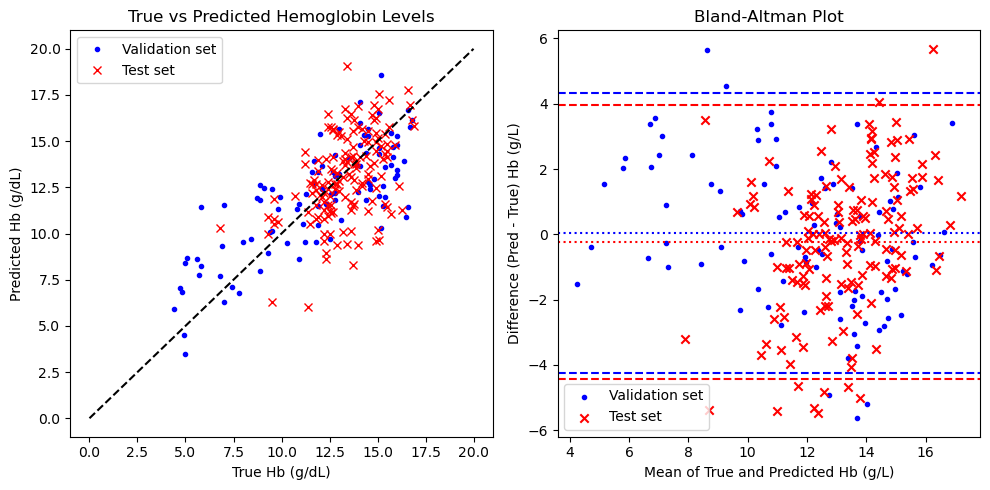

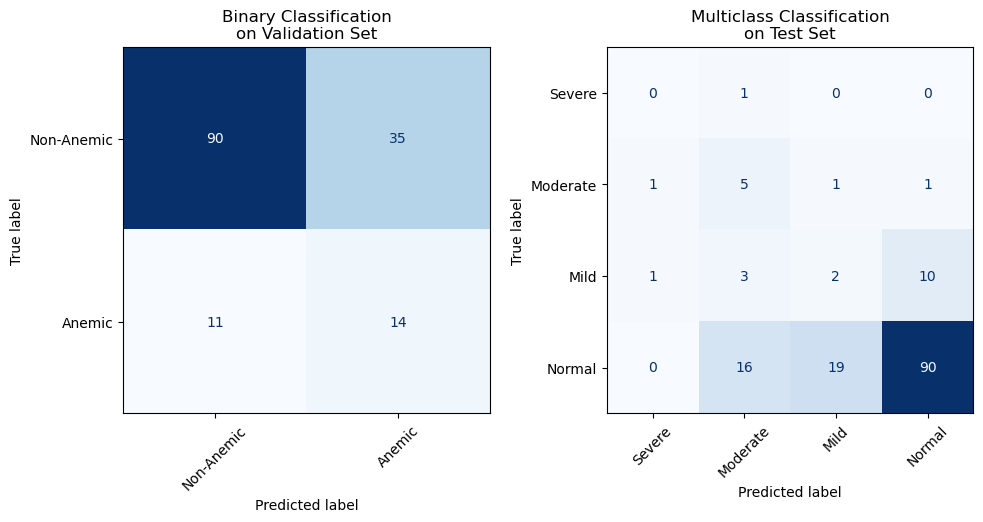

Fitting 7 folds for each of 10 candidates, totalling 70 fits


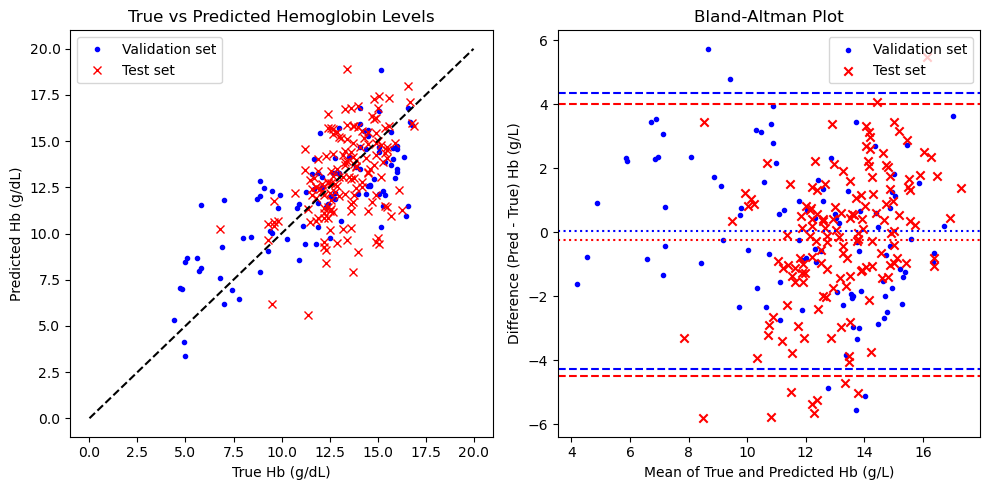

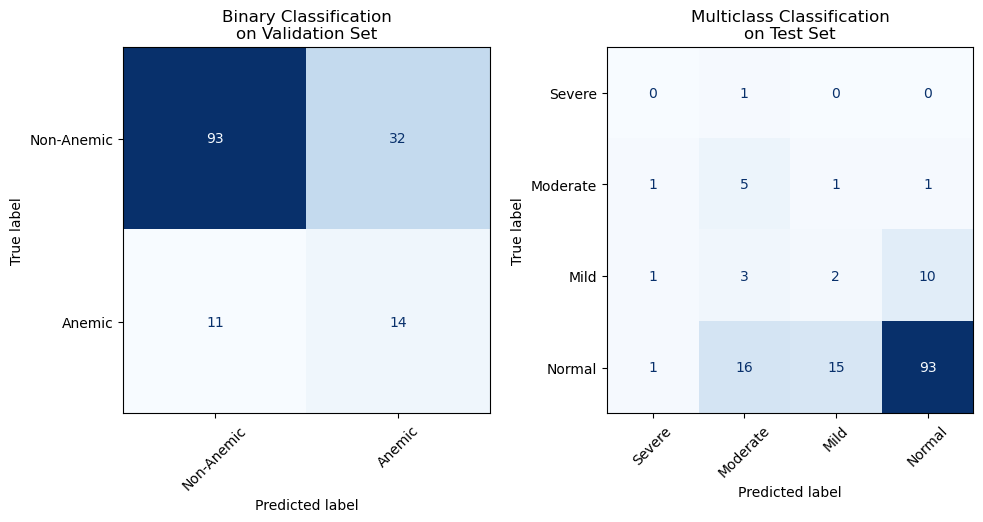

Fitting 7 folds for each of 10 candidates, totalling 70 fits


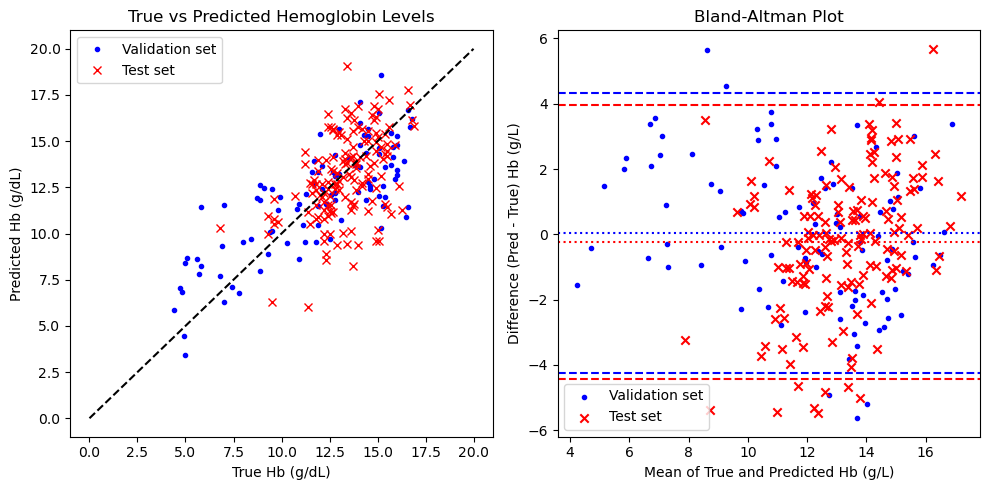

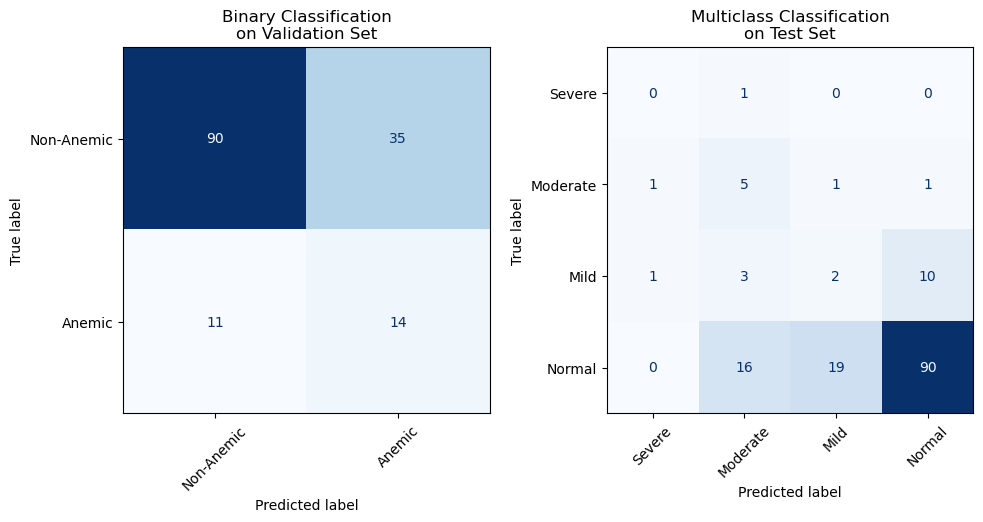

Fitting 7 folds for each of 4 candidates, totalling 28 fits


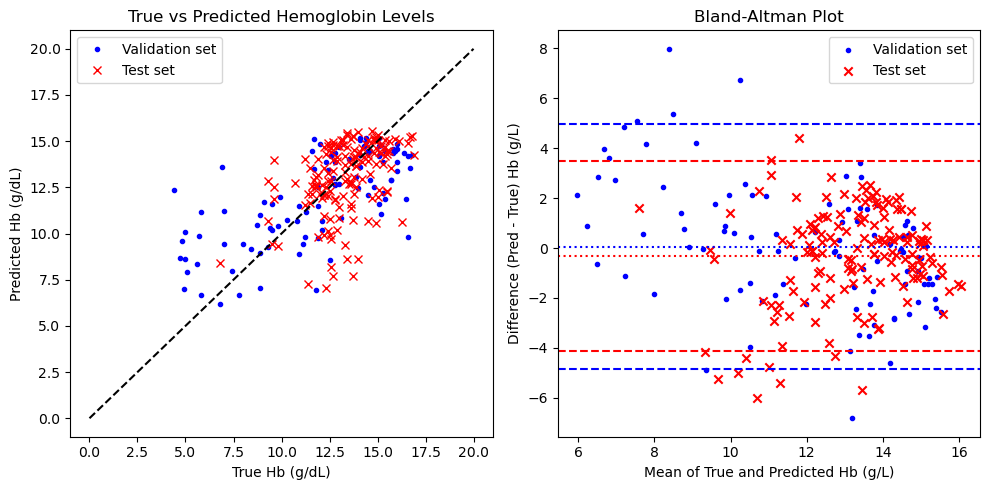

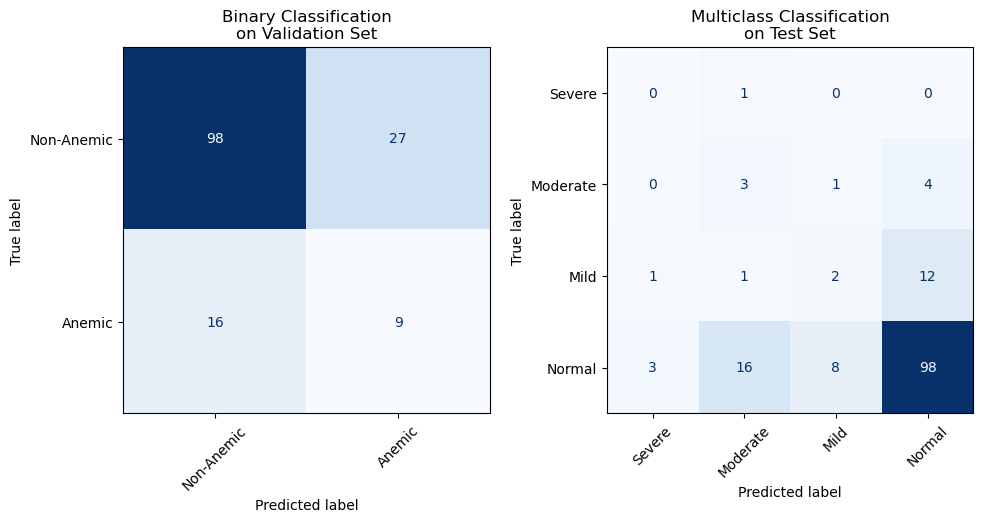

Fitting 7 folds for each of 4 candidates, totalling 28 fits


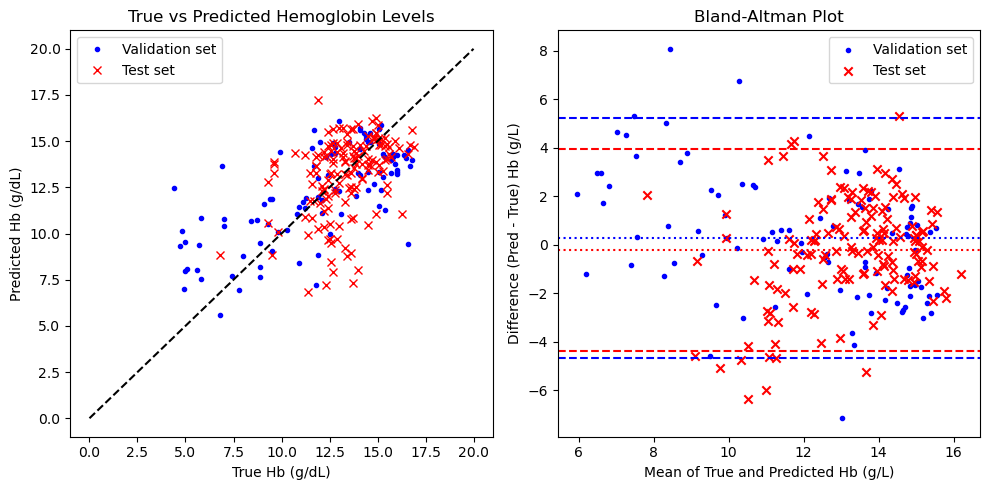

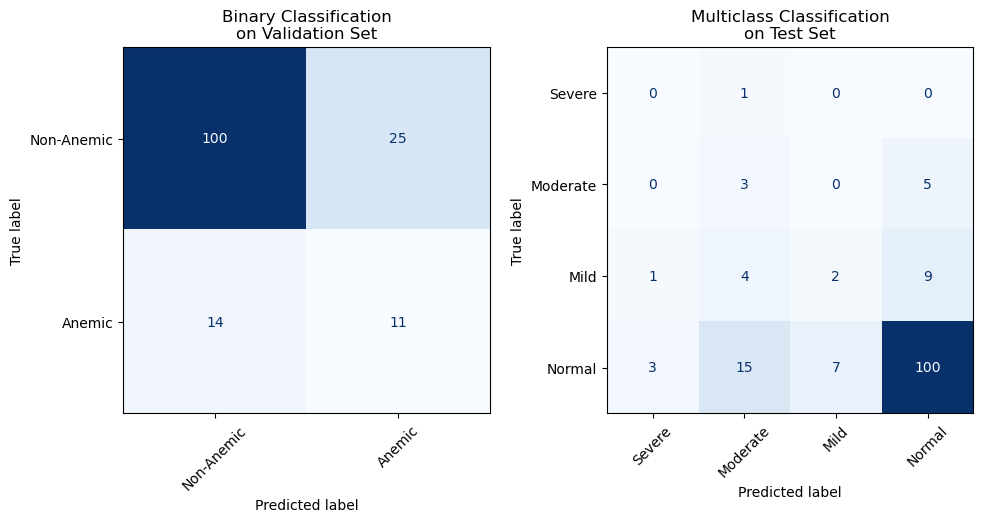

Fitting 7 folds for each of 6 candidates, totalling 42 fits


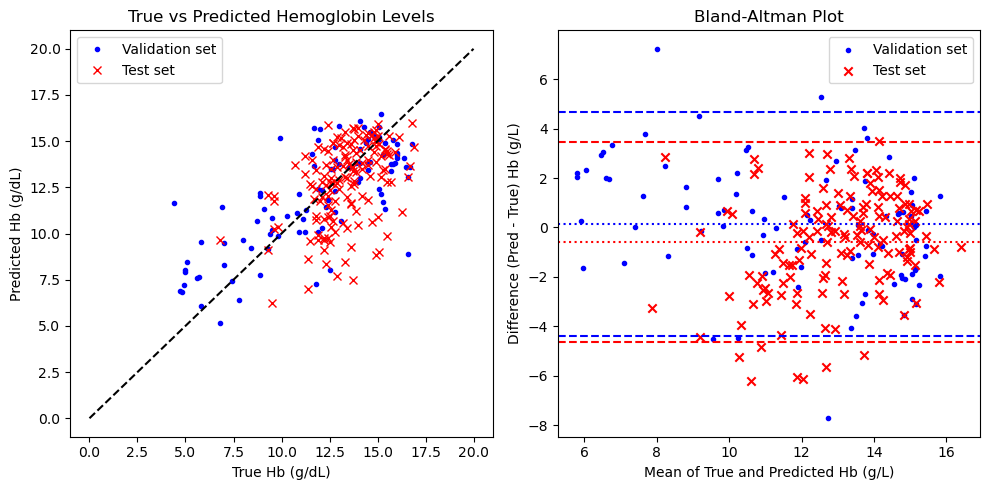

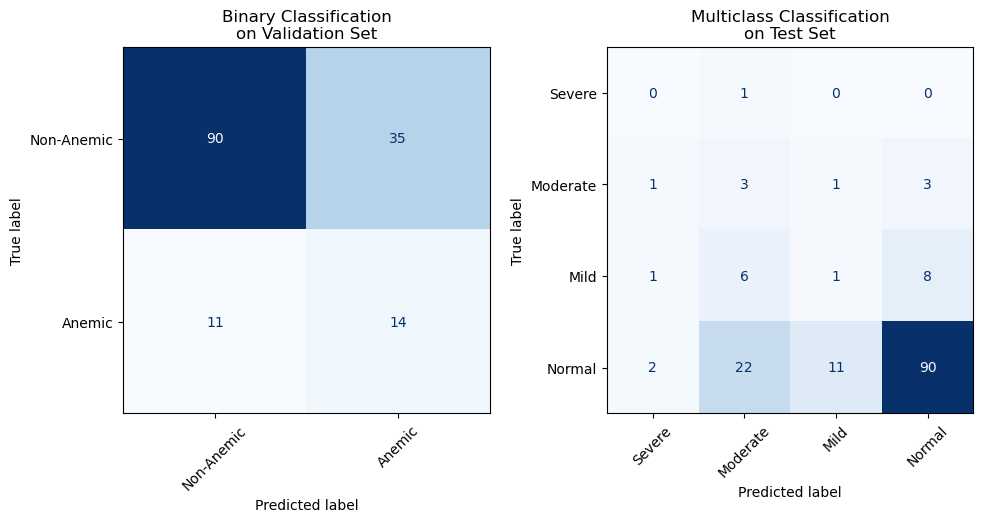

Fitting 7 folds for each of 2 candidates, totalling 14 fits


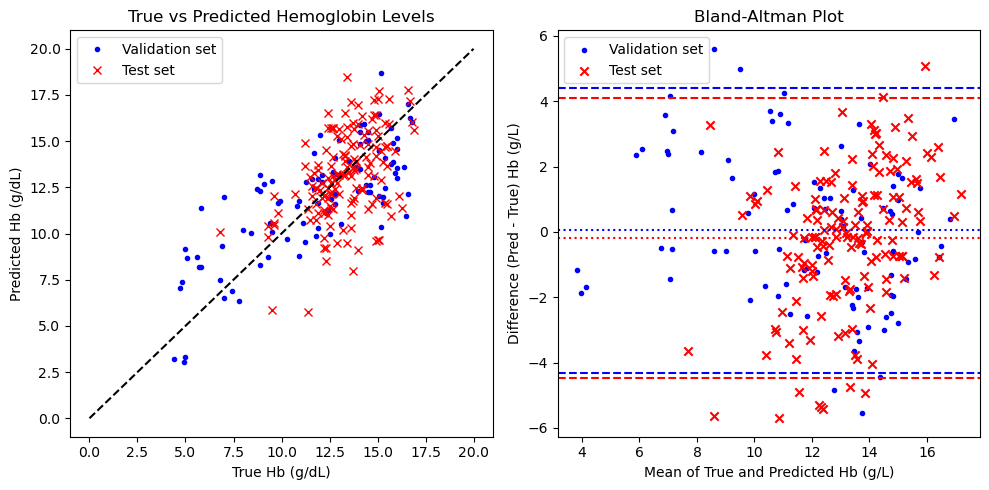

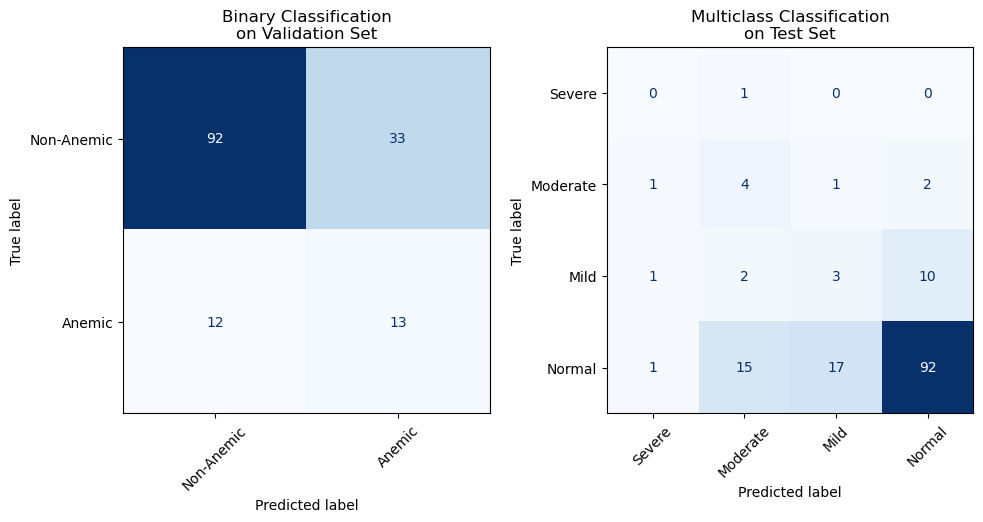

Fitting 7 folds for each of 2 candidates, totalling 14 fits


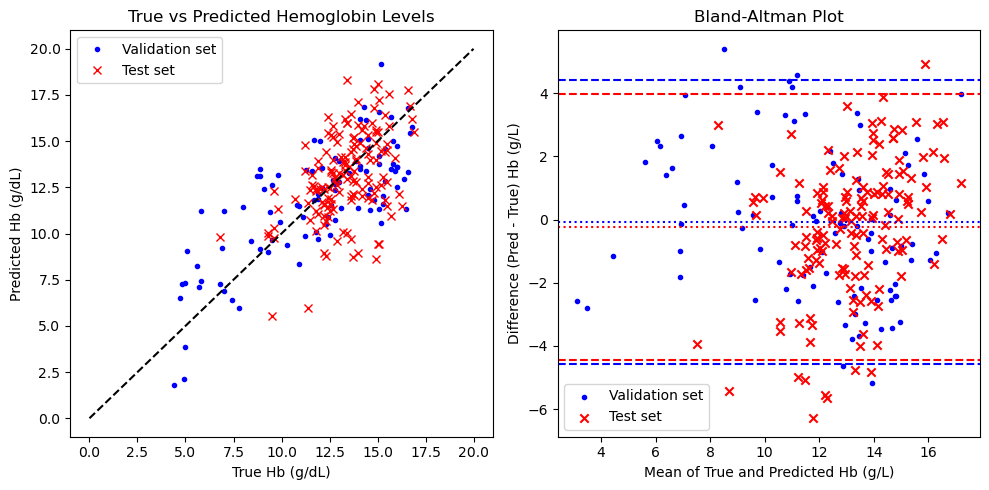

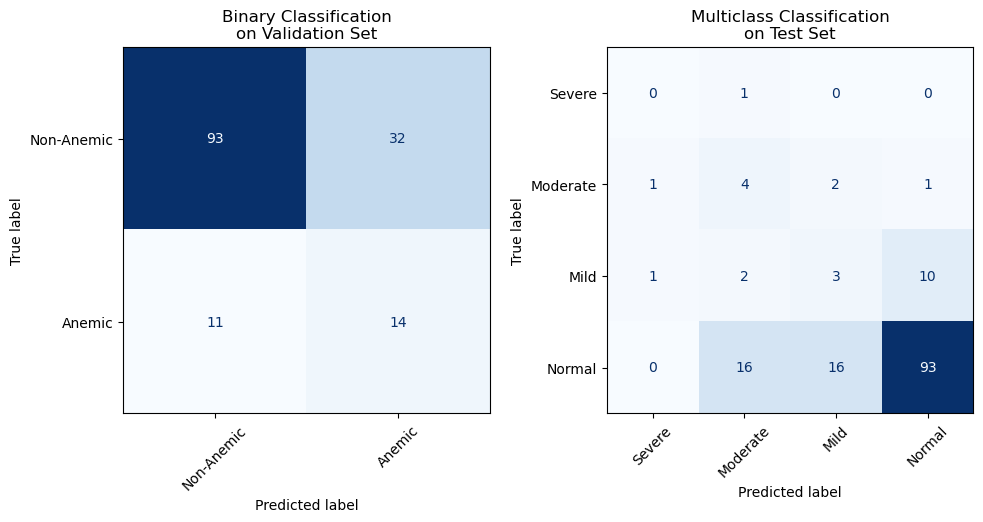

In [14]:
X = features[balancing_mask]
y = target[balancing_mask]

X_test = features[~balancing_mask]
y_test = target[~balancing_mask]

cv_scheme = KFold(n_splits=7)
scoring = make_scorer(mean_squared_error, greater_is_better=False, squared=False)

models = {
    "ElasticNet": ElasticNet(max_iter=10000),
    "Ridge": Ridge(max_iter=10000),
    "Lasso": Lasso(max_iter=10000),
    "RandomForest": RandomForestRegressor(),
    "GradientBoosting": GradientBoostingRegressor(),
    "SupportVectorRegression": SVR(),
    "HuberRegressor": HuberRegressor(),
    "RANSACRegressor": RANSACRegressor()
}

param_grids = {
    "ElasticNet": {'regressor__l1_ratio': [0.01, 0.1, 0.5, 0.9, 0.99],
                   'regressor__alpha': np.logspace(-4, 4, num=10)}, 
    "Ridge": {'regressor__alpha': np.logspace(-4, 4, num=10)},
    "Lasso": {'regressor__alpha': np.logspace(-4, 4, num=10)},
    "RandomForest": {'regressor__n_estimators': [50, 100],
                     'regressor__max_depth': [5, 10]},
    "GradientBoosting": {'regressor__n_estimators': [50, 100],
                         'regressor__learning_rate': [0.01, 0.1]},
    "SupportVectorRegression": {'regressor__C': [0.1, 1, 10],
                                'regressor__epsilon': [0.1, 0.2]},
    "HuberRegressor": {'regressor__epsilon': [1.1, 1.35]},
    "RANSACRegressor": {'regressor__min_samples': [0.5, 0.75]}
}

results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', RobustScaler()),
        ('regressor', model)
    ])
    grid = GridSearchCV(pipeline, param_grids[name], cv=cv_scheme, scoring=scoring, return_train_score=True, verbose=1)
    grid.fit(X, y)
    best_model = grid.best_estimator_
    y_pred_val = cross_val_predict(best_model, X, y, cv=cv_scheme)
    best_model.fit(X, y)
    y_pred_test = best_model.predict(X_test)
    val_mae = mean_absolute_error(y, y_pred_val)
    val_mse = mean_squared_error(y, y_pred_val, squared=True)
    val_rmse = mean_squared_error(y, y_pred_val, squared=False)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_mse = mean_squared_error(y_test, y_pred_test, squared=True)
    test_rmse = mean_squared_error(y_test, y_pred_test, squared=False)

    # Bland-Altman and scatter plot
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    # Plot 1: True vs Predicted
    axs[0].plot(y, y_pred_val, 'b.', label='Validation set')
    axs[0].plot(y_test, y_pred_test, 'rx', label='Test set')
    axs[0].plot([0,20], [0,20], 'k--')
    axs[0].set_title("True vs Predicted Hemoglobin Levels")
    axs[0].set_xlabel("True Hb (g/dL)")
    axs[0].set_ylabel("Predicted Hb (g/dL)")
    axs[0].legend()

    # Plot 2: Bland-Altman
    sets = [[y, y_pred_val, 'Validation set'], [y_test, y_pred_test, 'Test set']]
    colors = {'Validation set': 'b', 'Test set': 'r'}
    markers = {'Validation set': '.', 'Test set': 'x'}

    for _true, _pred, _label in sets:
        _avg = (_true + _pred) / 2
        _diff = _pred - _true
        _bias = np.mean(_diff)
        _SD = np.std(_diff)
        
        axs[1].scatter(_avg, _diff, label=_label, color=colors[_label], marker=markers[_label])
        axs[1].axhline(_bias, color=colors[_label], linestyle='dotted')
        axs[1].axhline(_bias + 1.96*_SD, color=colors[_label], linestyle='dashed')
        axs[1].axhline(_bias - 1.96*_SD, color=colors[_label], linestyle='dashed')

    axs[1].set_title("Bland-Altman Plot")
    axs[1].set_xlabel("Mean of True and Predicted Hb (g/L)")
    axs[1].set_ylabel("Difference (Pred - True) Hb (g/L)")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

    # Binary classification
    true_labels = y_test < 12.0
    pred_labels = y_pred_test < 12.0

    true_severity = np.array([classify_severity(h) for h in y_test])
    pred_severity = np.array([classify_severity(h) for h in y_pred_test])

    # Compute confusion matrices [ [TN, FP], [FN, TP] ]
    binary_cm = confusion_matrix(true_labels, pred_labels)
    tn, fp, fn, tp = binary_cm.ravel()
    sensitivity = tp / (tp + fn)  # Recall or True Positive Rate
    specificity = tn / (tn + fp)
    # print(f"Binary Classification: \nSensitivity (Recall, Anemia detection): {sensitivity:.2f} \t Specificity (Normal Hb detection): {specificity:.2f}")

    multiclass_cm = confusion_matrix(true_severity, pred_severity)
    multiclass_labels = ["Severe", "Moderate", "Mild", "Normal"]
    # import pdb;pdb.set_trace()
    sensitivity_list = []
    specificity_list = []

    for i in range(len(multiclass_labels)):
        TP = multiclass_cm[i, i]
        FN = np.sum(multiclass_cm[i, :]) - TP
        FP = np.sum(multiclass_cm[:, i]) - TP
        TN = np.sum(multiclass_cm) - (TP + FP + FN)

        sen = TP / (TP + FN) if (TP + FN) > 0 else 0
        spe = TN / (TN + FP) if (TN + FP) > 0 else 0
        sensitivity_list.append(sen)
        specificity_list.append(spe)

    # # Display per class
    # print("Class-wise Sensitivity (Recall):")
    # for i, sen in enumerate(sensitivity_list):
    #     print(f"{multiclass_labels[i]}: {sen:.2f}")

    # print("\nClass-wise Specificity:")
    # for i, spe in enumerate(specificity_list):
    #     print(f"{multiclass_labels[i]}: {spe:.2f}")

    # Plot side-by-side
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    # Binary CM
    ConfusionMatrixDisplay(binary_cm, display_labels=["Non-Anemic", "Anemic"]).plot(ax=axs[0], cmap="Blues", colorbar=False)
    axs[0].set_title("Binary Classification\non Validation Set")
    axs[0].tick_params(axis='x', rotation=45)

    # Multiclass CM
    ConfusionMatrixDisplay(multiclass_cm, display_labels=multiclass_labels).plot(ax=axs[1], cmap="Blues", colorbar=False)
    axs[1].set_title("Multiclass Classification\non Test Set")
    axs[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    model = best_model.named_steps["regressor"]
    scaler = best_model.named_steps["scaler"]
    X_explain_scaled = scaler.transform(X[:100])
    X_background_scaled = scaler.transform(X)

    # if name in ["Random Forest", "Gradient Boosting"]:
    #     explainer = shap.TreeExplainer(model)  # model = fitted RandomForest or GradientBoosting
    #     shap_values = explainer.shap_values(X_explain_scaled)
    #     shap.summary_plot(shap_values, features=X, feature_names=[f"feat. {i}" for i in range(X.shape[1])], max_display=10)

    # elif name == "Support Vector Regression":
    #     explainer = shap.KernelExplainer(model.predict, shap.sample(X_background_scaled, 100))
    #     shap_values = explainer.shap_values(X_explain_scaled)
    #     shap.summary_plot(shap_values, features=X, feature_names=[f"f{i}" for i in range(X.shape[1])], max_display=10)

    # else:
    #     explainer = shap.LinearExplainer(model, X_background_scaled)
    #     shap_values = explainer(X_explain_scaled)
    #     shap.summary_plot(shap_values, features=X, feature_names=[f"f{i}" for i in range(X.shape[1])], max_display=10)

    path = f"/Users/romerocruzsa/Workspace/Projects/Research/cp-anemia-detection/weights/best_{name.lower()}_model.pkl"
    joblib.dump(best_model, path)
    
    results.append((name, sensitivity, specificity, sensitivity_list, specificity_list, 
                    val_mae, val_mse, val_rmse, test_mae, test_mse, test_rmse))

In [15]:
results_df = pd.DataFrame(results, columns=["Model", "Senstivity (Binary)", "Specificity (Binary)",
                                             "Sensitivity (Multiclass)", "Specificity (Multiclass)",
                                             "Validation MAE", "Validation MSE", "Validation RMSE",
                                             "Test MAE", "Test MSE", "Test RMSE"])
import ace_tools_open as tools; tools.display_dataframe_to_user(name="Model Comparison: Hemoglobin Regression", dataframe=results_df)

Model Comparison: Hemoglobin Regression


0.276 	 0.750


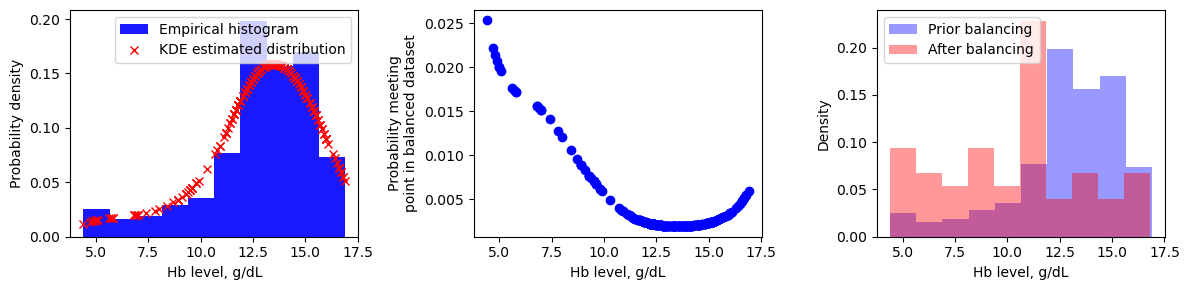

In [16]:
# Add severity class to metadata
metadata["SEVERITY"] = [classify_severity(hb) for hb in target]

# KDE balancing within each severity class
balanced_ids = []
samples_per_class = 15  # ~12-13 samples from each of 4 classes for ~50 total

for severity_class in range(4):
    class_mask = metadata["SEVERITY"] == severity_class
    class_targets = target[class_mask]
    class_ids = metadata.loc[class_mask, "PATIENT_ID"].values
    
    if len(class_ids) < samples_per_class:
        continue  # Avoid sampling more than available
    
    class_kde = stats.gaussian_kde(class_targets, bw_method=0.5)(class_targets)
    class_weights = 1 / class_kde
    class_weights /= class_weights.sum()
    
    sampled_ids = np.random.choice(class_ids, size=samples_per_class, replace=False, p=class_weights)
    balanced_ids.extend(sampled_ids)

# Final balanced mask
balanced_patient_ids = np.array(balanced_ids)
balancing_mask = metadata["PATIENT_ID"].isin(balanced_patient_ids).values

# Visualization
plt.figure(figsize=(12, 3))

plt.subplot(1, 3, 1)
target_kde = stats.gaussian_kde(target, bw_method=0.5)(target)
plt.hist(target, density=True, label='Empirical histogram', color='b', alpha=0.9)
plt.plot(target, target_kde, 'x', color='r', label='KDE estimated distribution')
plt.legend()
plt.ylabel("Probability density")
plt.xlabel("Hb level, g/dL")

plt.subplot(1, 3, 2)
weights = 1 / target_kde
weights /= np.sum(weights)
plt.plot(target, weights, 'o', color='b')
plt.ylabel("Probability meeting\npoint in balanced dataset")
plt.xlabel("Hb level, g/dL")

plt.subplot(1, 3, 3)
plt.hist(target, density=True, alpha=0.4, label='Prior balancing', color='b')
plt.hist(target[balancing_mask], density=True, alpha=0.4, label='After balancing', color='r')
plt.xlabel("Hb level, g/dL")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()

# Show anemia class balance before/after
print(f"{np.mean(target < 12.0):.3f} \t {np.mean(target[balancing_mask] < 12.0):.3f}")

# Final balanced data
X = features[balancing_mask]
y = target[balancing_mask]

****************************************************************************************************
Model: ELASTICNET
****************************************************************************************************
Fitting 7 folds for each of 50 candidates, totalling 350 fits


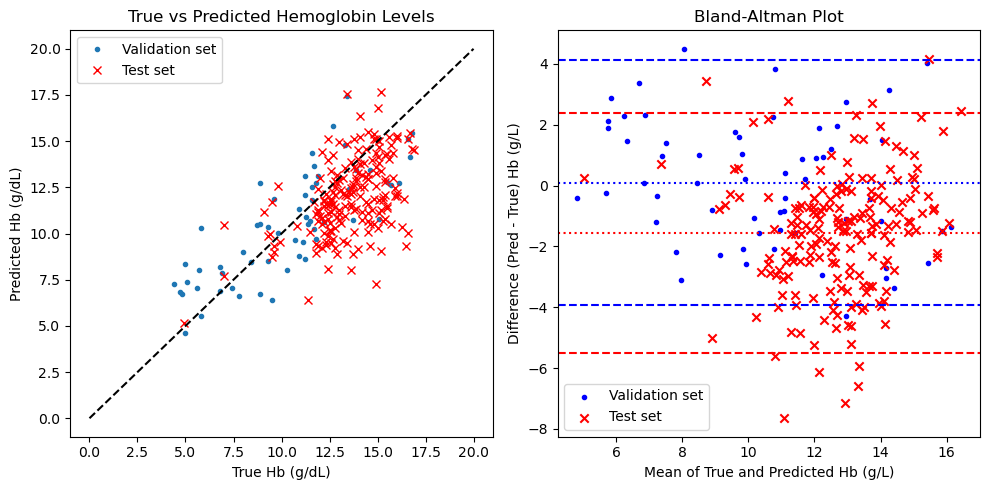

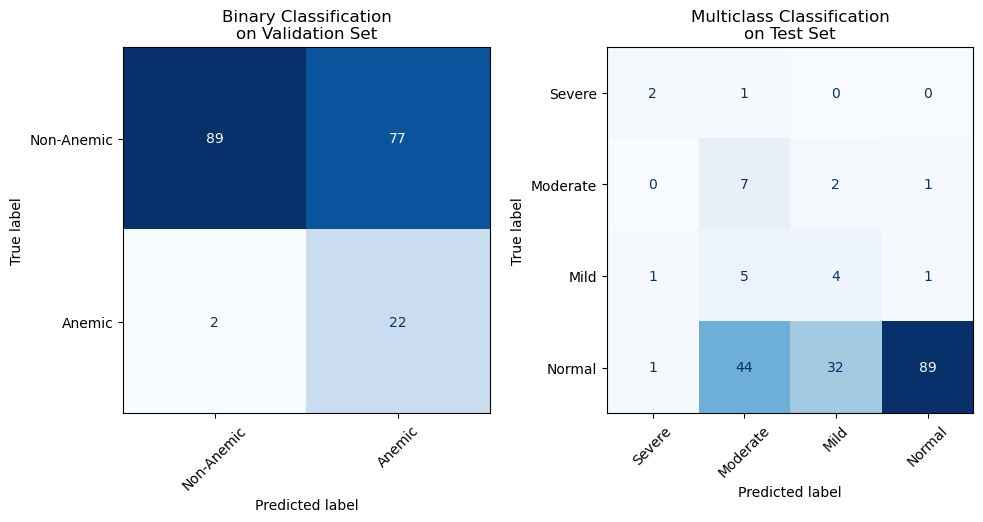

****************************************************************************************************
Model: RIDGE
****************************************************************************************************
Fitting 7 folds for each of 10 candidates, totalling 70 fits


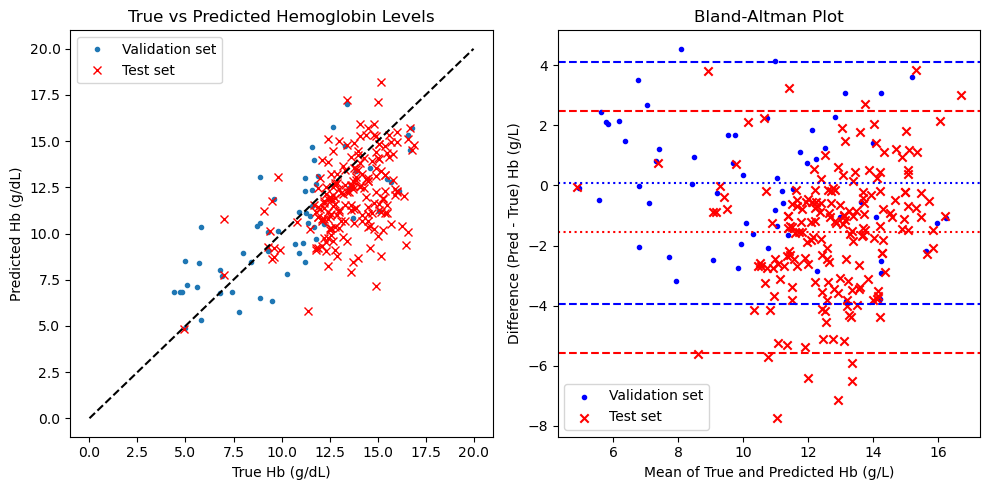

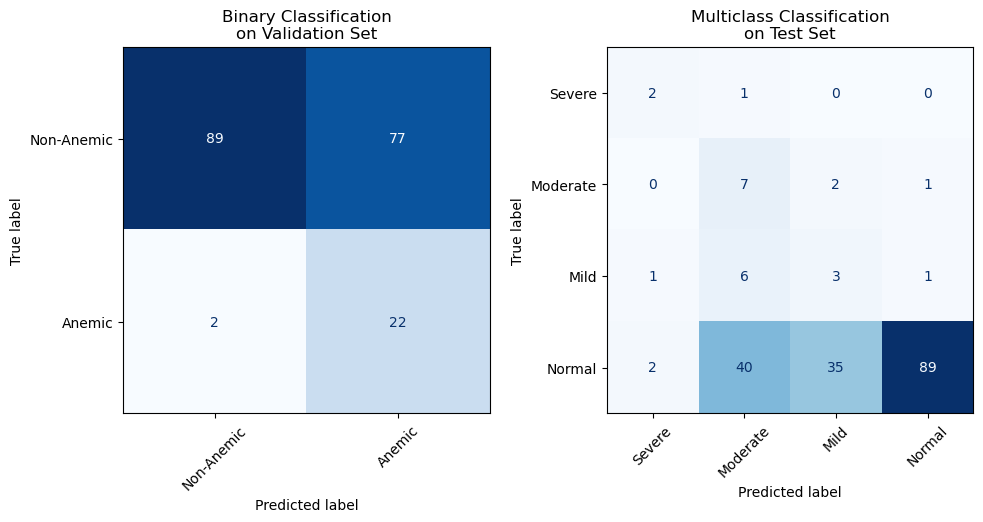

****************************************************************************************************
Model: LASSO
****************************************************************************************************
Fitting 7 folds for each of 10 candidates, totalling 70 fits


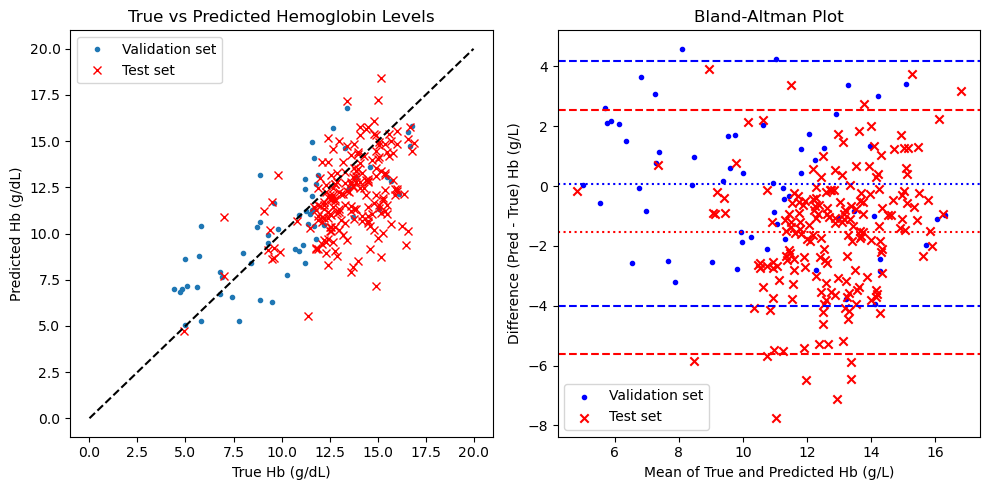

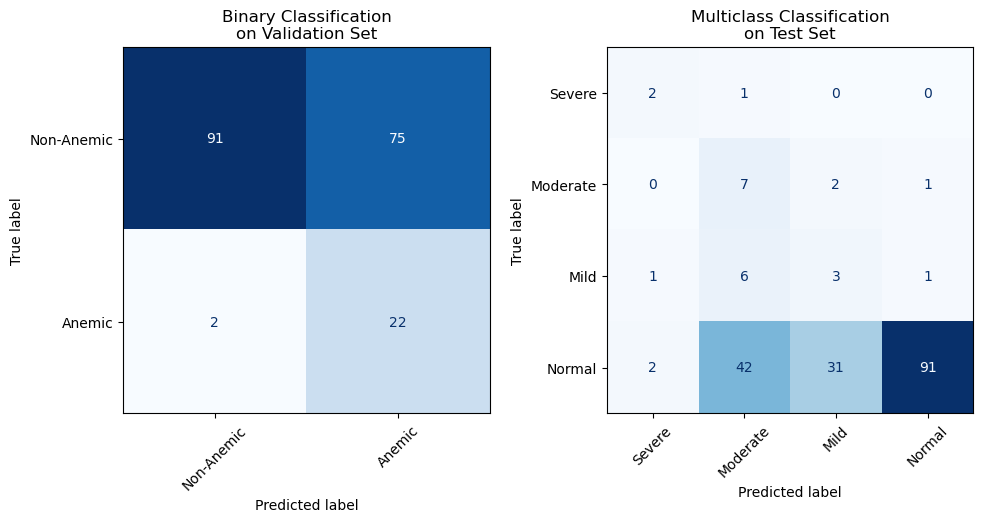

****************************************************************************************************
Model: RANDOMFOREST
****************************************************************************************************
Fitting 7 folds for each of 4 candidates, totalling 28 fits


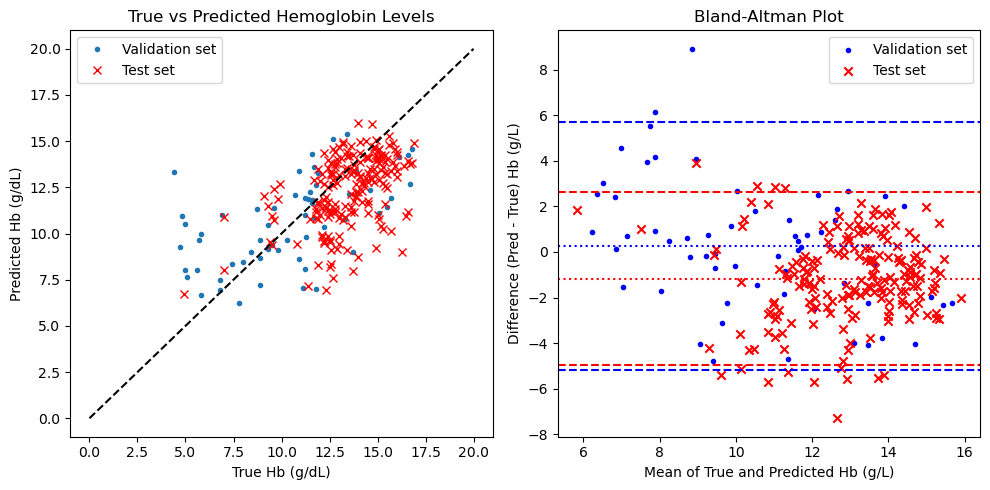

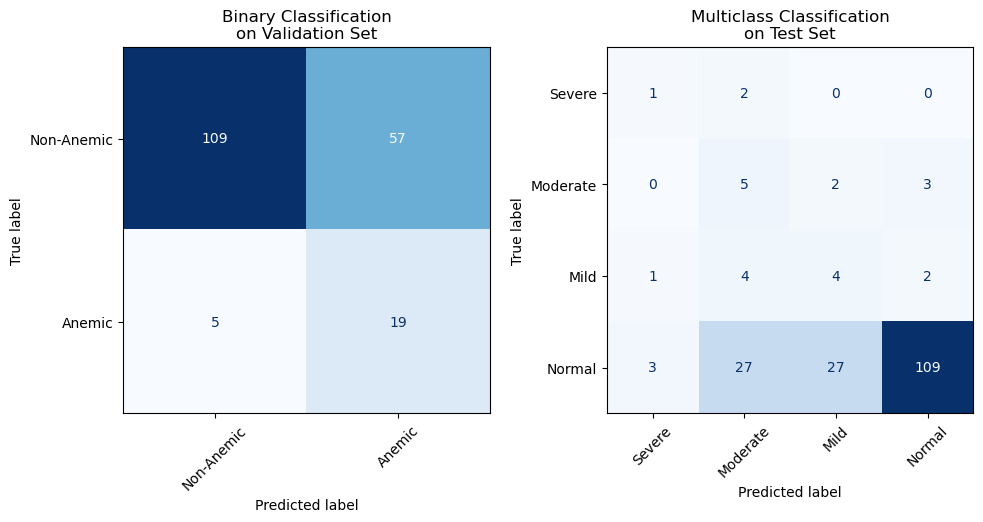

****************************************************************************************************
Model: GRADIENTBOOSTING
****************************************************************************************************
Fitting 7 folds for each of 4 candidates, totalling 28 fits


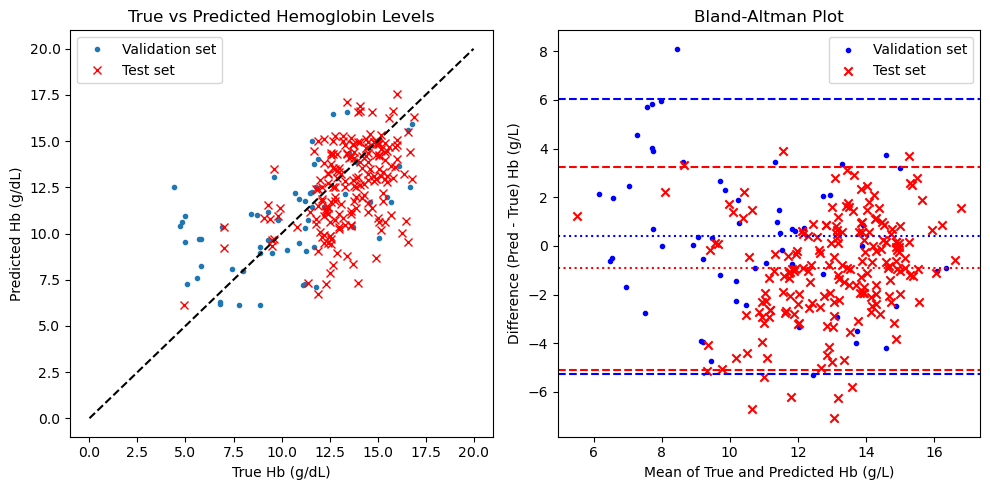

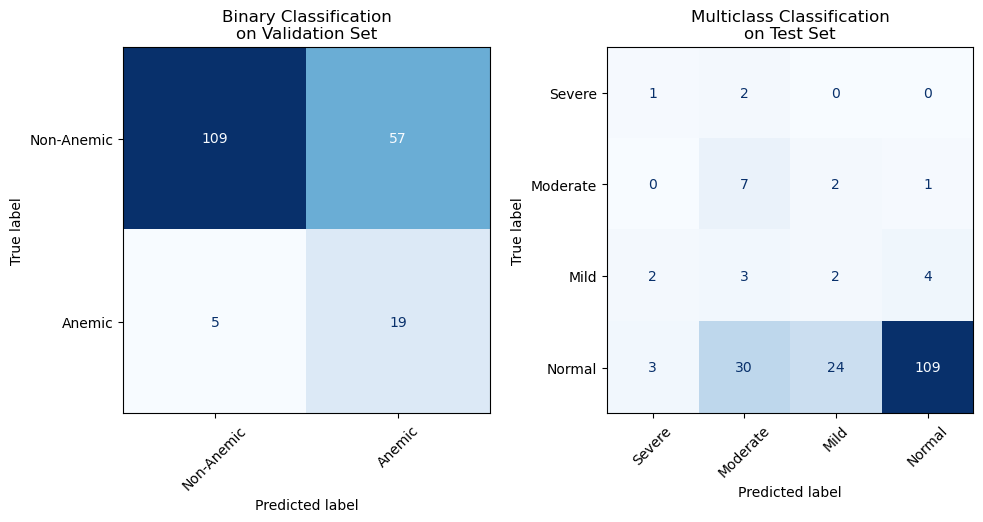

****************************************************************************************************
Model: SUPPORTVECTORREGRESSION
****************************************************************************************************
Fitting 7 folds for each of 6 candidates, totalling 42 fits


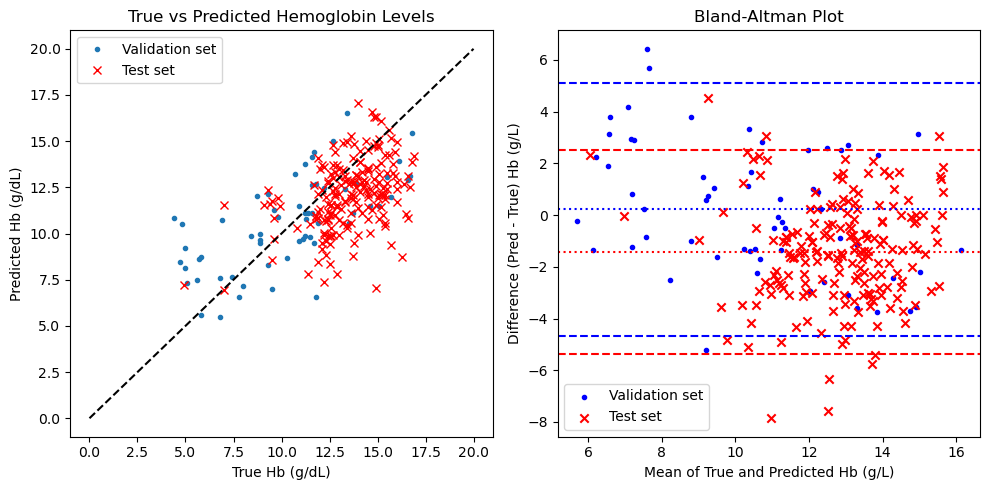

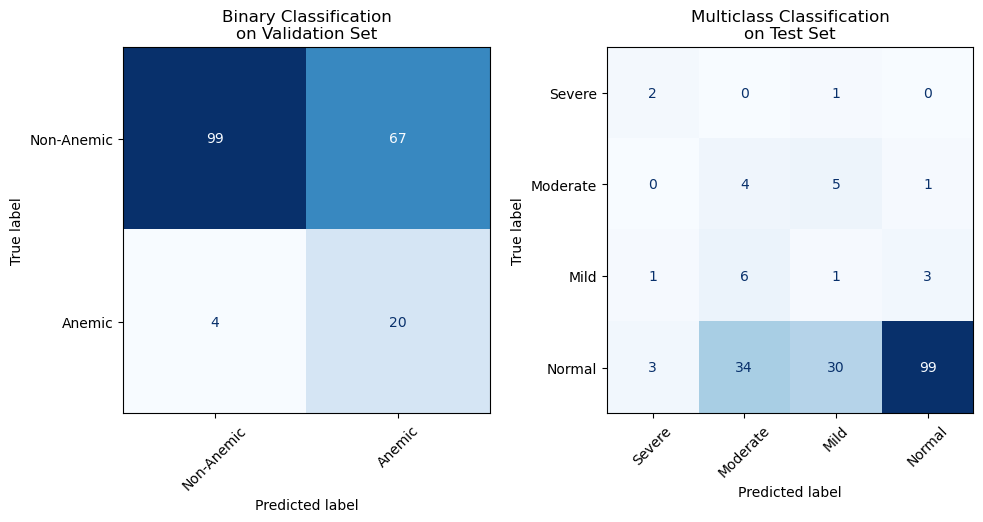

****************************************************************************************************
Model: HUBERREGRESSOR
****************************************************************************************************
Fitting 7 folds for each of 2 candidates, totalling 14 fits


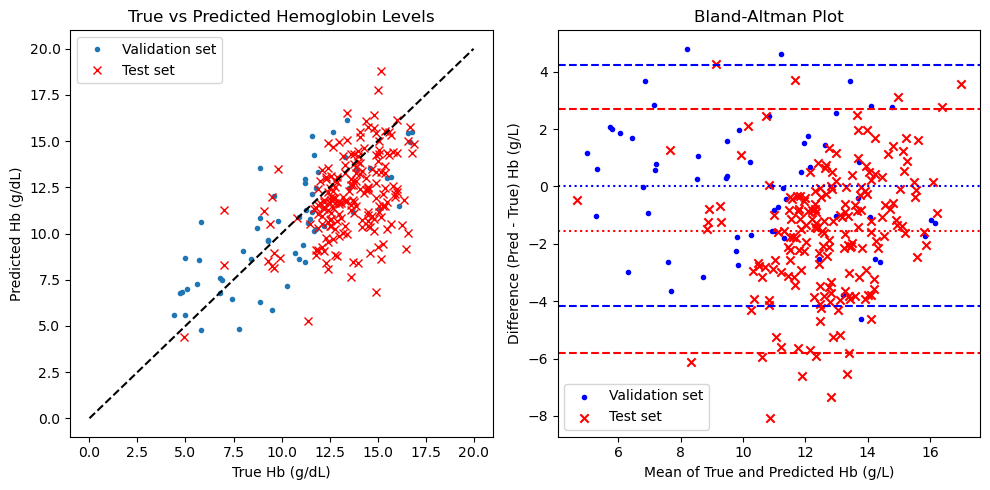

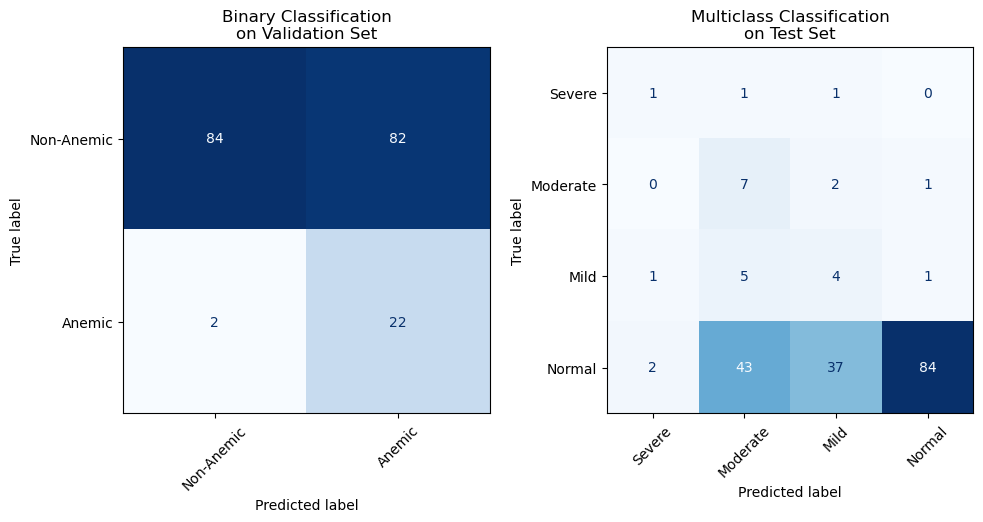

****************************************************************************************************
Model: RANSACREGRESSOR
****************************************************************************************************
Fitting 7 folds for each of 2 candidates, totalling 14 fits


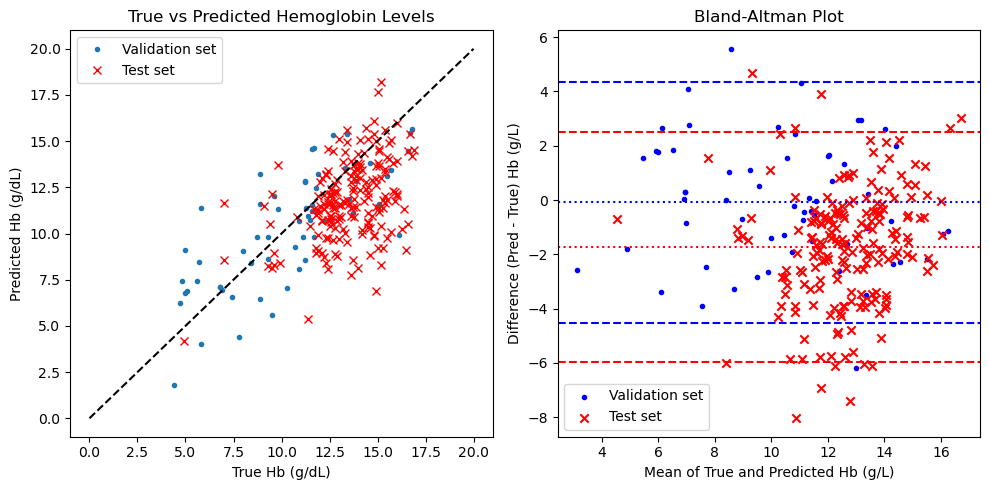

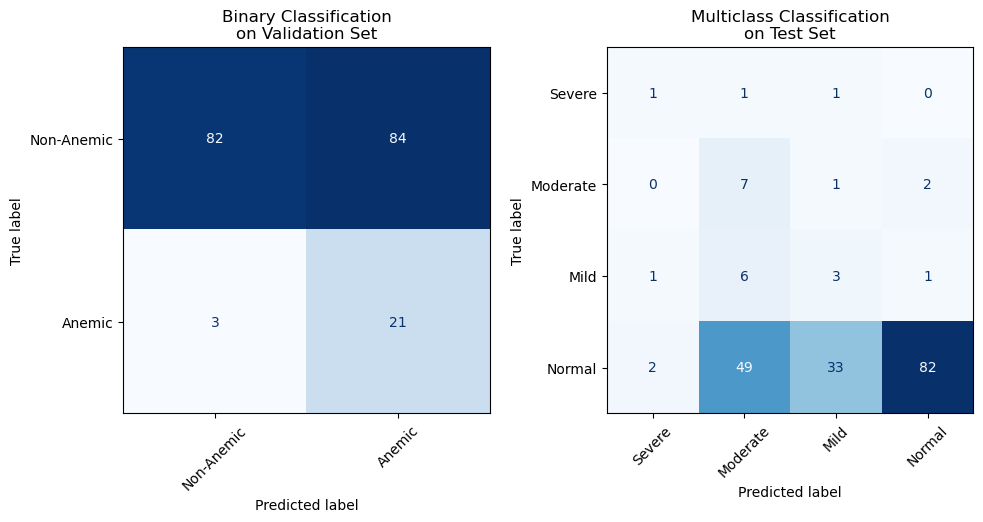

In [17]:
X = features[balancing_mask]
y = target[balancing_mask]

X_test = features[~balancing_mask]
y_test = target[~balancing_mask]

cv_scheme = KFold(n_splits=7)
scoring = make_scorer(mean_squared_error, greater_is_better=False, squared=False)

models = {
    "ElasticNet": ElasticNet(max_iter=10000),
    "Ridge": Ridge(max_iter=10000),
    "Lasso": Lasso(max_iter=10000),
    "RandomForest": RandomForestRegressor(),
    "GradientBoosting": GradientBoostingRegressor(),
    "SupportVectorRegression": SVR(),
    "HuberRegressor": HuberRegressor(),
    "RANSACRegressor": RANSACRegressor()
}

param_grids = {
    "ElasticNet": {'regressor__l1_ratio': [0.01, 0.1, 0.5, 0.9, 0.99],
                   'regressor__alpha': np.logspace(-4, 4, num=10)}, 
    "Ridge": {'regressor__alpha': np.logspace(-4, 4, num=10)},
    "Lasso": {'regressor__alpha': np.logspace(-4, 4, num=10)},
    "RandomForest": {'regressor__n_estimators': [50, 100],
                     'regressor__max_depth': [5, 10]},
    "GradientBoosting": {'regressor__n_estimators': [50, 100],
                         'regressor__learning_rate': [0.01, 0.1]},
    "SupportVectorRegression": {'regressor__C': [0.1, 1, 10],
                                'regressor__epsilon': [0.1, 0.2]},
    "HuberRegressor": {'regressor__epsilon': [1.1, 1.35]},
    "RANSACRegressor": {'regressor__min_samples': [0.5, 0.75]}
}

results = []

for name, model in models.items():
    print("*"*100)
    print(f"Model: {name.upper()}")
    print("*"*100)
    pipeline = Pipeline([
        ('scaler', RobustScaler()),
        ('regressor', model)
    ])
    grid = GridSearchCV(pipeline, param_grids[name], cv=cv_scheme, scoring=scoring, return_train_score=True, verbose=1)
    grid.fit(X, y)
    best_model = grid.best_estimator_
    y_pred_val = cross_val_predict(best_model, X, y, cv=cv_scheme)
    best_model.fit(X, y)
    y_pred_test = best_model.predict(X_test)
    val_mae = mean_absolute_error(y, y_pred_val)
    val_mse = mean_squared_error(y, y_pred_val, squared=True)
    val_rmse = mean_squared_error(y, y_pred_val, squared=False)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_mse = mean_squared_error(y_test, y_pred_test, squared=True)
    test_rmse = mean_squared_error(y_test, y_pred_test, squared=False)

    # Bland-Altman and scatter plot
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    # Plot 1: True vs Predicted
    axs[0].plot(y, y_pred_val, '.', label='Validation set')
    axs[0].plot(y_test, y_pred_test, 'rx', label='Test set')
    axs[0].plot([0,20], [0,20], 'k--')
    axs[0].set_title("True vs Predicted Hemoglobin Levels")
    axs[0].set_xlabel("True Hb (g/dL)")
    axs[0].set_ylabel("Predicted Hb (g/dL)")
    axs[0].legend()

    # Plot 2: Bland-Altman
    sets = [[y, y_pred_val, 'Validation set'], [y_test, y_pred_test, 'Test set']]
    colors = {'Validation set': 'b', 'Test set': 'r'}
    markers = {'Validation set': '.', 'Test set': 'x'}

    for _true, _pred, _label in sets:
        _avg = (_true + _pred) / 2
        _diff = _pred - _true
        _bias = np.mean(_diff)
        _SD = np.std(_diff)
        
        axs[1].scatter(_avg, _diff, label=_label, color=colors[_label], marker=markers[_label])
        axs[1].axhline(_bias, color=colors[_label], linestyle='dotted')
        axs[1].axhline(_bias + 1.96*_SD, color=colors[_label], linestyle='dashed')
        axs[1].axhline(_bias - 1.96*_SD, color=colors[_label], linestyle='dashed')

    axs[1].set_title("Bland-Altman Plot")
    axs[1].set_xlabel("Mean of True and Predicted Hb (g/L)")
    axs[1].set_ylabel("Difference (Pred - True) Hb (g/L)")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

    # Binary classification
    true_labels = y_test < 12.0
    pred_labels = y_pred_test < 12.0

    true_severity = np.array([classify_severity(h) for h in y_test])
    pred_severity = np.array([classify_severity(h) for h in y_pred_test])

    # Compute confusion matrices [ [TN, FP], [FN, TP] ]
    binary_cm = confusion_matrix(true_labels, pred_labels)
    tn, fp, fn, tp = binary_cm.ravel()
    sensitivity = tp / (tp + fn)  # Recall or True Positive Rate
    specificity = tn / (tn + fp)
    # print(f"Binary Classification: \nSensitivity (Recall, Anemia detection): {sensitivity:.2f} \t Specificity (Normal Hb detection): {specificity:.2f}")

    multiclass_cm = confusion_matrix(true_severity, pred_severity)
    multiclass_labels = ["Severe", "Moderate", "Mild", "Normal"]
    # import pdb;pdb.set_trace()
    sensitivity_list = []
    specificity_list = []

    for i in range(len(multiclass_labels)):
        TP = multiclass_cm[i, i]
        FN = np.sum(multiclass_cm[i, :]) - TP
        FP = np.sum(multiclass_cm[:, i]) - TP
        TN = np.sum(multiclass_cm) - (TP + FP + FN)

        sen = TP / (TP + FN) if (TP + FN) > 0 else 0
        spe = TN / (TN + FP) if (TN + FP) > 0 else 0
        sensitivity_list.append(sen)
        specificity_list.append(spe)

    # # Display per class
    # print("Class-wise Sensitivity (Recall):")
    # for i, sen in enumerate(sensitivity_list):
    #     print(f"{multiclass_labels[i]}: {sen:.2f}")

    # print("\nClass-wise Specificity:")
    # for i, spe in enumerate(specificity_list):
    #     print(f"{multiclass_labels[i]}: {spe:.2f}")
    # Plot side-by-side
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    # Binary CM
    ConfusionMatrixDisplay(binary_cm, display_labels=["Non-Anemic", "Anemic"]).plot(ax=axs[0], cmap="Blues", colorbar=False)
    axs[0].set_title("Binary Classification\non Validation Set")
    axs[0].tick_params(axis='x', rotation=45)

    # Multiclass CM
    ConfusionMatrixDisplay(multiclass_cm, display_labels=multiclass_labels).plot(ax=axs[1], cmap="Blues", colorbar=False)
    axs[1].set_title("Multiclass Classification\non Test Set")
    axs[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    model = best_model.named_steps["regressor"]
    scaler = best_model.named_steps["scaler"]
    X_explain_scaled = scaler.transform(X[:100])
    X_background_scaled = scaler.transform(X)

    # if name in ["Random Forest", "Gradient Boosting"]:
    #     explainer = shap.TreeExplainer(model)  # model = fitted RandomForest or GradientBoosting
    #     shap_values = explainer.shap_values(X_explain_scaled)
    #     shap.summary_plot(shap_values, features=X, feature_names=[f"feat. {i}" for i in range(X.shape[1])], max_display=10)

    # elif name == "Support Vector Regression":
    #     explainer = shap.KernelExplainer(model.predict, shap.sample(X_background_scaled, 100))
    #     shap_values = explainer.shap_values(X_explain_scaled)
    #     shap.summary_plot(shap_values, features=X, feature_names=[f"f{i}" for i in range(X.shape[1])], max_display=10)
        
    # else:
    #     explainer = shap.LinearExplainer(model, X_background_scaled)
    #     shap_values = explainer(X_explain_scaled)
    #     shap.summary_plot(shap_values, features=X, feature_names=[f"f{i}" for i in range(X.shape[1])], max_display=10)

    path = f"/Users/romerocruzsa/Workspace/Projects/Research/cp-anemia-detection/weights/best_{name.lower()}_model.pkl"
    joblib.dump(best_model, path)
    
    results.append((name, sensitivity, specificity, sensitivity_list, specificity_list, 
                    val_mae, val_mse, val_rmse, test_mae, test_mse, test_rmse))


In [18]:
results_df = pd.DataFrame(results, columns=["Model", "Senstivity (Binary)", "Specificity (Binary)",
                                             "Sensitivity (Multiclass)", "Specificity (Multiclass)",
                                             "Validation MAE", "Validation MSE", "Validation RMSE",
                                             "Test MAE", "Test MSE", "Test RMSE"])
import ace_tools_open as tools; tools.display_dataframe_to_user(name="Model Comparison: Hemoglobin Regression", dataframe=results_df)

Model Comparison: Hemoglobin Regression
